<a href="https://colab.research.google.com/github/JanTeichertKluge/demand-analysis-labs/blob/main/v2/02_finetune_embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2: Fine-Tuning the Product Embeddings

> **This notebook needs a GPU.** In Colab: *Runtime, Change runtime type, T4 GPU* or
> better. On a free T4, training fills most of a three-hour session. If Colab
> disconnects, run the notebook again: training resumes after the last finished epoch.

Lab 1 ended with a regression saying demand is almost perfectly inelastic, which cannot be
right. The controls we are missing are product quality and visibility. We never observe
either as a number, but both are described in the product text and shown in the product
image.

This notebook turns that text and those images into numbers. It trains a multimodal
network (RoBERTa for text, BEiT for images, SAINT for the tabular block) and writes the
resulting embeddings to disk for Labs 3, 4 and 5.

## Why not use off-the-shelf embeddings?

A pre-trained encoder gives a representation optimised for the objective it was trained
on, such as masked-token prediction or image classification. Nothing about that objective
makes the representation good at predicting price and quantity, which is what we need.

So we fine-tune. Following the paper, the network has two prediction heads, one for the
quantity signal and one for the price signal, and minimises

$$
L = \bigl\|Q_{it} - \hat{l}(X^{in}_i)\bigr\|_{\text{pred},2} \cdot
      \bigl\|P_{it} - \hat{m}(X^{in}_i)\bigr\|_{\text{pred},2},
$$

the product of the two root-mean-square prediction errors. These are the same two nuisance
functions the partialling-out estimator in Lab 4 needs, $\hat{l} \approx E[Q \mid S]$ and
$\hat{m} \approx E[P \mid S]$. The paper calls training the representation on this
objective **causal fine-tuning**: the embedding is shaped by the estimation problem it
will be used for rather than by a generic pre-training task.

## The architecture

$$
X^{in}_i = \begin{pmatrix}\text{Text}_i \\ \text{Image}_i \\ \text{Tabular}_i\end{pmatrix}
\;\xrightarrow{\;e\;}\;
E_i = \begin{pmatrix}T_i \\ I_i \\ \mathrm{Tab}_i\end{pmatrix}
\;\xrightarrow{\;m\;}\;
\{\hat{Q}_{it}, \hat{P}_{it}\}
$$

Each encoder emits a dense vector. The vectors are layer-normalised and concatenated into
$E_i \in \mathbb{R}^{2048}$ (768 text, 768 image, and 32 for each of the 16 tabular columns). Two small MLP heads read
that embedding and predict the two signals. Gradients flow back into the transformers, so
the embedding itself adapts.

Fine-tuning uses the fine-tune products only. Labs 4 and 5 estimate elasticities on the
estimation products, whose embeddings the network produced but never trained on. The
paper's Addendum A relies on that independence when it shows the DML inference is
unaffected by having estimated the embeddings.

## What varies over time

The description and the image do not change over time, but part of the tabular block does:
the offer counts, the lightning-deal flag and the Buy Box fulfilment flag are observed every
period. Following the paper's pipeline we therefore compute the embedding for every
product-period. The text and image parts, 1536 of the 2048 dimensions, are identical across a
product's periods, so most of the embedding cannot explain *changes* in price. Lab 3 measures
this and Labs 4 and 5 build on it.

## Setup

The install needs some explanation. `doubleml-deep` imports its SAINT tabular model when
the package is imported, so `pytorch-widedeep` has to be importable even though we barely
use it. Installing it normally pulls in `spacy`, `gensim` and `opencv` and pins
`numpy<2`, which downgrades numpy underneath Colab's pre-installed torch, pandas and scipy
and breaks the runtime.

Instead we install it with `--no-deps` and supply two small stub modules for the text
utilities that `pytorch-widedeep` imports but that we never call. Everything else
(`torchvision`, `cv2`, `wrapt`) is already on Colab.

In [1]:
%pip install -q lightning torchmetrics einops doubleml
%pip install -q --no-deps pytorch-widedeep
%pip install -q git+https://github.com/DoubleML/doubleml-deep.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import os
import sys
import pathlib

# --- shim: satisfy pytorch-widedeep's unused text-utility imports -----------
# pytorch_widedeep.utils.text_utils imports gensim and spacy at module level.
# We never tokenise text with them (RoBERTa does that), so tiny stubs suffice
# and we avoid the numpy<2 downgrade their real versions would force.
SHIM = "/content/_wd_shim" if os.path.isdir("/content") else "_wd_shim"
for pkg in ("gensim", "spacy"):
    pathlib.Path(f"{SHIM}/{pkg}").mkdir(parents=True, exist_ok=True)

pathlib.Path(f"{SHIM}/gensim/__init__.py").write_text("")
pathlib.Path(f"{SHIM}/gensim/utils.py").write_text(
    "def tokenize(*a, **k):\n    raise NotImplementedError('gensim stub')\n")
pathlib.Path(f"{SHIM}/spacy/__init__.py").write_text(
    "__version__ = '0.0.0-stub'\n\n\n"
    "class Language:  # datasets.utils._dill checks issubclass(obj, spacy.Language)\n"
    "    pass\n\n\n"
    "def blank(*a, **k):\n    raise NotImplementedError('spacy stub')\n\n\n"
    "def load(*a, **k):\n    raise NotImplementedError('spacy stub')\n")
pathlib.Path(f"{SHIM}/spacy/symbols.py").write_text("ORTH = 65\n")

if SHIM not in sys.path:
    sys.path.insert(0, SHIM)

In [3]:
import warnings

# Suppress DeprecationWarning
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ResourceWarning)

In [4]:
import gc
import glob
import io
import time
import urllib.request

import numpy as np
import pandas as pd
import torch
import lightning.pytorch as pl
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from torch.utils.data import DataLoader
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.random_projection import GaussianRandomProjection

from doubleml_deep import DoubleMLLightning
from doubleml_deep.plm import DoubleMLPLRDeep
from doubleml_deep.default_models import (
    DoubleMLDeepBeitModel,
    DoubleMLDeepRobertaModel,
    DoubleMLDeepSaintModel,
)

palette = sns.color_palette("colorblind")

if torch.cuda.is_available():
    name = torch.cuda.get_device_name(0)
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {name} ({vram:.0f} GB)")
else:
    raise RuntimeError(
        "No GPU visible, so this notebook would train on CPU and take hours.\n"
        "Go to Runtime, Change runtime type, and pick a GPU (T4 is enough).\n"
        "TPU runtimes do not work here: torch sees no CUDA device and silently\n"
        "falls back to CPU. Supporting TPUs would need torch-xla.\n"
        "To override anyway, set ALLOW_CPU = True."
    )

GPU: Tesla T4 (16 GB)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Mount Google Drive now rather than at the end. Training writes a checkpoint there after
every epoch (about 3.5 GB), so a session that disconnects can pick up where it stopped, and
the finished artifact goes there for Labs 3 to 5.

In [5]:
DRIVE_DIR = None
try:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_DIR = "/content/drive/MyDrive/demand_labs_v2"
    os.makedirs(DRIVE_DIR, exist_ok=True)
    print(f"checkpoints and artifact go to {DRIVE_DIR}")
except Exception as exc:
    print(f"Drive not mounted ({type(exc).__name__}); checkpoints and artifact stay local "
          "and are lost when the session ends.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
checkpoints and artifact go to /content/drive/MyDrive/demand_labs_v2


## Rebuilding the subsample

Same constants, same deterministic draw and same 1,540 products as Lab 1. If you changed
`N_PRODUCTS` there, change it here too.

In [6]:
# ---------------------------------------------------------------------------
# Configuration. Keep this cell identical in Labs 1 and 2.
# ---------------------------------------------------------------------------
BASE = ("https://raw.githubusercontent.com/JanTeichertKluge/"
        "demand-analysis-repro/main/main/data")

N_PRODUCTS = 1540  # products in the subsample
N_FINETUNE = 770   # of those, the ones Lab 2 trains on (the paper's I_1)
SEED = 42

panel_files = [
    "amzn_toys_monthly_diffs_ffill_fixed_splits_buybox/train-00000-of-00002.parquet",
    "amzn_toys_monthly_diffs_ffill_fixed_splits_buybox/train-00001-of-00002.parquet",
    "amzn_toys_monthly_diffs_ffill_fixed_splits_buybox/validation-00000-of-00002.parquet",
    "amzn_toys_monthly_diffs_ffill_fixed_splits_buybox/validation-00001-of-00002.parquet",
]

# An image file holds a fixed set of products and cannot be queried for a single
# product, so these five files determine the pool we draw from: 3,300 images, of
# which 1,540 belong to a product with a complete panel. Add more parts from the
# same folder for a larger sample.
image_files = [
    "amzn_toys_monthly_avg_long_ffill_28_7_images/train-00000-of-00004-part000.parquet",
    "amzn_toys_monthly_avg_long_ffill_28_7_images/train-00001-of-00004-part000.parquet",
    "amzn_toys_monthly_avg_long_ffill_28_7_images/train-00002-of-00004-part000.parquet",
    "amzn_toys_monthly_avg_long_ffill_28_7_images/train-00003-of-00004-part000.parquet",
    "amzn_toys_monthly_avg_long_ffill_28_7_images/train-00000-of-00004-part001.parquet",
]

os.makedirs("data_cache", exist_ok=True)
for remote in panel_files + image_files:
    local = "data_cache/" + remote.split("/")[-1]
    if not os.path.exists(local):
        print("downloading", local, flush=True)
        urllib.request.urlretrieve(f"{BASE}/{remote}", local)

print("data ready (~500 MB, cached for this session)")

data ready (~500 MB, cached for this session)


In [7]:
columns = ["ASIN", "window", "date", "SALES_RANK", "BUYBOX_PRICE", "text",
           "RATING", "REVIEW_COUNT", "subcat_aggregated",
           "New Offer Count: Current",
           "Count of retrieved live offers: New, FBA",
           "Count of retrieved live offers: New, FBM",
           "Lightning Deals: Upcoming Deal", "Buy Box: Is FBA"]

panel = pd.concat([pd.read_parquet("data_cache/" + f.split("/")[-1], columns=columns)
                   for f in panel_files], ignore_index=True)

# Keep the 28-day time averages, then every fourth week: 14 four-week periods
# from 2023-01-30 to 2024-01-29. SALES_RANK is already log(1 / sales rank) and
# BUYBOX_PRICE already log(price), so they are the paper's Q_it and P_it.
panel = panel[panel["window"] == 28].drop(columns="window")
dates = np.sort(panel["date"].unique())
panel["date_t"] = panel["date"].map({d: i for i, d in enumerate(dates)})
panel = panel[(panel["date_t"] <= 54) & (panel["date_t"] % 4 == 0)].dropna()
panel["period"] = panel["date_t"] // 4
panel = panel.rename(columns={"SALES_RANK": "Q_t", "BUYBOX_PRICE": "P_bb_t"})

# Eligible products: we have an image, and they are observed in all 14 periods.
have_image = set(pd.concat(
    [pd.read_parquet("data_cache/" + f.split("/")[-1], columns=["ASIN"])
     for f in image_files], ignore_index=True)["ASIN"])
n_periods = panel.groupby("ASIN")["period"].nunique()
candidates = np.array(sorted(set(n_periods[n_periods == 14].index) & have_image))

# Deterministic draw, then a split by product. Labs 4 and 5 estimate only on
# the "estimation" products, so the embeddings they use were fitted on different
# products. The paper's Addendum A relies on that independence.
rng = np.random.default_rng(SEED)
chosen = np.sort(rng.choice(candidates, size=N_PRODUCTS, replace=False))
finetune = set(chosen[rng.permutation(N_PRODUCTS)[:N_FINETUNE]])

df = panel[panel["ASIN"].isin(set(chosen))].sort_values(["ASIN", "period"])
df = df.reset_index(drop=True)
df["split"] = np.where(df["ASIN"].isin(finetune), "finetune", "estimation")

# Lagged state and first differences, within product
grouped = df.groupby("ASIN")
df["Q_t-1"] = grouped["Q_t"].shift(1)
df["P_bb_t-1"] = grouped["P_bb_t"].shift(1)
df["RATING_t-1"] = grouped["RATING"].shift(1)
df["REVIEW_COUNT_t-1"] = grouped["REVIEW_COUNT"].shift(1)
df["Delta_Q_t"] = df["Q_t"] - df["Q_t-1"]
df["Delta_P_bb_t"] = df["P_bb_t"] - df["P_bb_t-1"]

print(f"{len(candidates):,} products qualify; using {N_PRODUCTS}")
print(df.groupby("split").agg(products=("ASIN", "nunique"), rows=("ASIN", "size")))

1,540 products qualify; using 1540
            products   rows
split                      
estimation       770  10780
finetune         770  10780


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Training settings

These are the settings of the paper's training script
(`_src_scrpts/training_level_v02_bert_hpc.py`, the time-independent text-and-image run).

In [8]:
torch.set_float32_matmul_precision("medium")

BATCH_SIZE = 16
ACCUMULATE_GRAD_BATCHES = 2   # optimizer step every 2 batches: effective batch of 32
LEARNING_RATE = 2e-5
MOMENTUM = 0.95               # passed through as in the script; AdamW ignores it
WD = 1e-6
SCHEDULER = None              # constant learning rate
GRADIENT_CLIP_VAL = 2
DROPOUT = 0.1
FUSION_HEAD = [256, 128]

MAX_EPOCHS = 10               # upper bound; early stopping ends the run sooner
PATIENCE = 2                  # epochs without improvement before stopping
MIN_DELTA = 0.001             # smallest drop in val_combined_loss that counts

# Colab: how long this session may train (the rest of the notebook needs about
# 30 minutes more), and whether to continue a run an earlier session started.
TRAIN_HOURS = 2
RESUME = True

# Validation decides when training stops and which epoch's weights we keep:
# every estimation product, observed in two periods.
VAL_PERIODS = [0, 7]

N_CLUSTERS = 5          # k in k-means, as in the paper
N_COMPONENTS = 5        # number of PCA / similarity features
PROJECTION_DIM = 256    # Johnson-Lindenstrauss target dimension

torch.manual_seed(SEED)
pl.seed_everything(SEED, workers=True)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


42

Source images are large: half of them are 1500 pixels wide or more, and the biggest are
2560 x 2560, which is 19 MB once decoded. We keep them encoded (about 110 KB each) and decode
one at a time when they are preprocessed below, so the image processor sees exactly the
image the paper's pipeline saw.

In [9]:
images = {}
for f in image_files:
    table = pd.read_parquet("data_cache/" + f.split("/")[-1])
    hit = table[table["ASIN"].isin(set(chosen))]
    images.update(zip(hit["ASIN"], (record["bytes"] for record in hit["image"])))
    del table, hit

megabytes = sum(len(b) for b in images.values()) / 1e6
print(f"{len(images):,} product images ({megabytes:.0f} MB, still encoded)")

1,540 product images (203 MB, still encoded)


## Assembling the inputs

The tabular block follows the paper's training script: the three offer counts
(standardised), the lightning-deal flag, the Buy Box FBA flag and the subcategory dummies.
Ratings, review counts and lagged price and quantity stay out of the network and enter
later as ordinary controls in Labs 3 to 5.

Rows are split by product. The network trains on every period of the fine-tune products, so
it sees each product 14 times with the same text and image but different targets and
tabular values. Validation uses every estimation product in two periods. Its loss decides
when training stops and which epoch's weights we keep, just as the paper's script
validated on its held-out products. The network never trains on these rows.

In [10]:
# Fixed category list, so the tabular input width does not depend on which
# products happen to be drawn.
SUBCATS = sorted(panel["subcat_aggregated"].unique())
SUBCAT_COLS = [f"sub_{c.replace(' ', '_').replace('&', 'and')}" for c in SUBCATS]

dummies = (pd.get_dummies(df["subcat_aggregated"])
           .reindex(columns=SUBCATS, fill_value=0)
           .astype("float32"))
dummies.columns = SUBCAT_COLS
df = pd.concat([df, dummies], axis=1)

# Network copies of the time-varying tabular inputs; the artifact keeps the raw
# values. The script fits one scaler per split. We fit on the fine-tune rows and
# apply it to every row, so the estimation products do not shape the scaling.
COUNT_COLS = ["New Offer Count: Current",
              "Count of retrieved live offers: New, FBA",
              "Count of retrieved live offers: New, FBM"]
FLAG_COLS = ["Lightning Deals: Upcoming Deal", "Buy Box: Is FBA"]
X_COUNT_COLS = ["x_n_offers", "x_n_offers_fba", "x_n_offers_fbm"]
X_FLAG_COLS = ["x_lightning_deal", "x_is_fba"]

scaler = StandardScaler().fit(df.loc[df["split"] == "finetune", COUNT_COLS])
df[X_COUNT_COLS] = scaler.transform(df[COUNT_COLS])
df[X_FLAG_COLS] = df[FLAG_COLS].astype("float32").to_numpy()

TAB_NET_COLS = X_COUNT_COLS + X_FLAG_COLS + SUBCAT_COLS
print(f"{len(TAB_NET_COLS)} tabular columns ({len(SUBCAT_COLS)} subcategory dummies) "
      f"-> SAINT embedding of {32 * len(TAB_NET_COLS)} dimensions")

# Row positions in df: every period of the fine-tune products for training,
# every estimation product in VAL_PERIODS for validation.
is_finetune = (df["split"] == "finetune").to_numpy()
train_rows = np.flatnonzero(is_finetune)
val_rows = np.flatnonzero(~is_finetune & df["period"].isin(VAL_PERIODS).to_numpy())
print(f"training rows:   {len(train_rows):,} ({df.loc[train_rows, 'ASIN'].nunique()} products)")
print(f"validation rows: {len(val_rows):,} ({df.loc[val_rows, 'ASIN'].nunique()} products)")

16 tabular columns (11 subcategory dummies) -> SAINT embedding of 512 dimensions
training rows:   10,780 (770 products)
validation rows: 1,540 (770 products)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## The model

`DoubleMLPLRDeep` builds the network sketched above. Two settings matter here.

Setting `embedding_dim=None` makes the fusion layer the identity, so the embedding we
extract later is the raw layer-normalised concatenation $E_i \in \mathbb{R}^{2048}$ rather
than a learned compression. The paper reduces dimension afterwards by random projection,
where there are distance-preservation guarantees. This setting also requires
`use_attention=False`.

Setting `score="partialling out"` with `combined_loss="multiplicative"` gives the loss
$L = \|Q - \hat l\|\cdot\|P - \hat m\|$ written above.

Building the model downloads roughly 600 MB of pre-trained weights.

In [11]:
data_field_map = {
    "outcome": ["Q_t"],
    "treatments": ["P_bb_t"],
    "tab_cols": {"cat_cols": [], "con_cols": TAB_NET_COLS},
    "txt_cols": ["text"],
    "img_cols": ["image"],
}

model_dict = {
    # SAINT with the package defaults, as in the script. With no categorical
    # columns, cat_embed_input=None does what the script's [] does.
    "tab": DoubleMLDeepSaintModel(tab_cols=data_field_map["tab_cols"],
                                  cat_embed_input=None),
    "txt": DoubleMLDeepRobertaModel(padding=True),
    "img": DoubleMLDeepBeitModel(),
}

dml_deep = DoubleMLPLRDeep(
    data_field_map=data_field_map,
    model_dict=model_dict,
    fusion_head=FUSION_HEAD,
    embedding_dim=None,      # identity fusion -> raw concatenated embedding
    use_attention=False,     # required when embedding_dim is None
    score="partialling out",
    combined_loss="multiplicative",
    dropout_prob=DROPOUT,
)

lit_model = DoubleMLLightning(
    dml_deep, optim="AdamW", lr=LEARNING_RATE, weight_decay=WD, momentum=MOMENTUM,
    scheduler=SCHEDULER,
    save_hyperparameters=False,   # otherwise every checkpoint pickles the whole network
)

EMB_DIM = dml_deep.network.embedding_network.embedding_dim
n_train = sum(p.numel() for p in lit_model.parameters() if p.requires_grad)
print(f"embedding dimension: {EMB_DIM}")
print(f"trainable parameters: {n_train / 1e6:.1f}M")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                        | Status     |  | 
---------------------------+------------+--+-
classifier.out_proj.weight | UNEXPECTED |  | 
classifier.out_proj.bias   | UNEXPECTED |  | 
classifier.dense.weight    | UNEXPECTED |  | 
classifier.dense.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/221 [00:00<?, ?it/s]

[transformers] BeitModel LOAD REPORT from: microsoft/beit-base-patch16-224-pt22k-ft22k
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


embedding dimension: 2048
trainable parameters: 217.9M


/usr/local/lib/python3.13/dist-packages/doubleml_deep/networks/embedding_network.py:48: UserWarning: attention_dim will be ignored because use_attention is False.
  warnings.warn(


## Feeding the network

`doubleml-deep` also ships a data module, `DoubleMLDeepData`, which tokenises and
preprocesses every row up front and keeps the result in memory. With 1,540 products the
training and validation rows alone would need about 8 GB for the preprocessed images, more
than a Colab session can spare. Descriptions and images do not change over time, so we
tokenise and preprocess each *product* once, with the same tokenizer and image processor, and
assemble every batch from these caches. The network receives exactly the inputs the data
module would give it; only memory use and preprocessing time differ.

As in the paper's script (`padding=True`), each batch pads its descriptions to the longest
one in the batch.

In [12]:
tokenizer = model_dict["txt"].preprocessor
products = df.drop_duplicates("ASIN").set_index("ASIN")

t0 = time.time()
token_ids = {a: model_dict["txt"].preprocess([text])["input_ids"][0]
             for a, text in products["text"].items()}
pixel_values = {}
for a in products.index:
    with Image.open(io.BytesIO(images[a])) as im:   # one full-size image at a time
        pixel_values[a] = model_dict["img"].preprocess(im.convert("RGB"))["pixel_values"][0]
gigabytes = sum(p.numel() * p.element_size() for p in pixel_values.values()) / 1e9
print(f"cached {len(token_ids):,} descriptions and {len(pixel_values):,} images "
      f"({gigabytes:.1f} GB) in {(time.time() - t0) / 60:.1f} min")

TARGET_TAB_COLS = ["Q_t", "P_bb_t"] + TAB_NET_COLS
row_values = torch.tensor(df[TARGET_TAB_COLS].to_numpy(dtype="float32"))
row_asins = df["ASIN"].to_numpy()


def collate(rows):
    """Assemble the network's input dict for a list of df row positions."""
    batch = dict(zip(TARGET_TAB_COLS, row_values[rows].T))
    ids = [token_ids[a] for a in row_asins[rows]]
    input_ids = torch.full((len(ids), max(map(len, ids))), tokenizer.pad_token_id)
    attention_mask = torch.zeros_like(input_ids)
    for i, t in enumerate(ids):   # pad to the longest description in the batch
        input_ids[i, :len(t)] = t
        attention_mask[i, :len(t)] = 1
    batch.update(input_ids=input_ids, attention_mask=attention_mask,
                 token_type_ids=torch.zeros_like(input_ids),
                 pixel_values=torch.stack([pixel_values[a] for a in row_asins[rows]]))
    return batch


def make_loader(rows, shuffle=False, drop_last=False):
    return DataLoader(rows.tolist(), batch_size=BATCH_SIZE, shuffle=shuffle,
                      drop_last=drop_last, collate_fn=collate,
                      generator=torch.Generator().manual_seed(SEED))


train_loader = make_loader(train_rows, shuffle=True, drop_last=True)
val_loader = make_loader(val_rows, drop_last=True)
print(f"{len(train_loader)} training batches per epoch, {len(val_loader)} validation batches")

cached 1,540 descriptions and 1,540 images (0.9 GB) in 0.7 min
673 training batches per epoch, 96 validation batches


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Training

AdamW at a constant learning rate of $2 \cdot 10^{-5}$,
weight decay $10^{-6}$, gradients clipped at norm 2 and accumulated over two batches, and
mixed precision. It runs for at most 10 epochs and stops early once the validation loss has gone 2 epochs without improving by at least 0.001. Afterwards we restore the weights from the
best epoch.

- *Session budget.* At the end of each epoch the run checks whether another epoch still fits
  into `TRAIN_HOURS`. If not, it stops there and the notebook carries on with the best
  weights so far.
- *Resume.* A full checkpoint goes to Drive after every epoch. Running the notebook again in
  a new session continues from it, with optimizer, epoch counter and early-stopping state
  intact. Once early stopping (or the epoch limit) has ended the run, later runs skip
  training and load the best weights. Set `RESUME = False` to start over.

**Runtime.** These are estimates, not benchmarks. Setup takes about 15 minutes, an epoch about 12 to 16 minutes on a T4, so one session of `TRAIN_HOURS = 1` trains roughly ten epochs. Extraction and the steps after it take about 20 minutes.

Each validation epoch also reports a full partialling-out DML estimate computed from the current network's predictions. Watching $\hat\theta$ settle across epochs is a useful diagnostic, though the estimate to trust is the one in Lab 4, computed on held-out products with cross-fitting.

If the GPU runs out of memory, lower `BATCH_SIZE` to 8 and raise `ACCUMULATE_GRAD_BATCHES`
to 4, which keeps the effective batch at 32.

In [13]:
RUN_DIR = os.path.join(DRIVE_DIR or ".", f"finetune_n{N_PRODUCTS}_ft{N_FINETUNE}_seed{SEED}")
RESUME_CKPT = os.path.join(RUN_DIR, "resume.ckpt")
DONE_FILE = os.path.join(RUN_DIR, "done.txt")
os.makedirs(RUN_DIR, exist_ok=True)
if not RESUME:
    for stale in (RESUME_CKPT, DONE_FILE):
        if os.path.exists(stale):
            os.remove(stale)


class SessionBudget(pl.Callback):
    """Print one line per epoch; stop at an epoch boundary before the budget runs out."""

    def __init__(self, hours):
        self.deadline = time.time() + 3600 * hours
        self.reached = False

    def on_train_start(self, trainer, pl_module):
        self.best = float(early_stopping.best_score)   # inf, or the restored best on resume

    def on_train_epoch_start(self, trainer, pl_module):
        self.epoch_start = time.time()

    def on_train_epoch_end(self, trainer, pl_module):
        now = time.time()
        loss = float(trainer.callback_metrics.get("val_combined_loss", float("nan")))
        self.best = min(self.best, loss)
        print(f"epoch {trainer.current_epoch:2d}: {(now - self.epoch_start) / 60:4.1f} min   "
              f"val_combined_loss {loss:.4f}   best {self.best:.4f}", flush=True)
        if not trainer.should_stop and now + 1.1 * (now - self.epoch_start) > self.deadline:
            self.reached = True
            trainer.should_stop = True


early_stopping = EarlyStopping(monitor="val_combined_loss", mode="min",
                               min_delta=MIN_DELTA, patience=PATIENCE)
best_ckpt = ModelCheckpoint(dirpath=RUN_DIR, filename="best-{epoch:03d}-{val_combined_loss:.4f}",
                            monitor="val_combined_loss", mode="min", save_top_k=1,
                            save_weights_only=True)
resume_ckpt = ModelCheckpoint(dirpath=RUN_DIR, filename="resume", save_top_k=1)  # full state, every epoch
budget = SessionBudget(TRAIN_HOURS)

trainer = pl.Trainer(
    accelerator="gpu",
    devices=1,
    precision="16-mixed",
    max_epochs=MAX_EPOCHS,
    gradient_clip_val=GRADIENT_CLIP_VAL,
    accumulate_grad_batches=ACCUMULATE_GRAD_BATCHES,
    callbacks=[early_stopping, best_ckpt, resume_ckpt, budget],
    logger=CSVLogger(save_dir=RUN_DIR, name="logs"),
    log_every_n_steps=20,
)

if "panel" in globals():
    del panel
gc.collect()

if RESUME and os.path.exists(DONE_FILE):
    with open(DONE_FILE) as fh:
        best_path = fh.read().strip()
    print("this run already finished in an earlier session; skipping training")
else:
    resume_from = RESUME_CKPT if RESUME and os.path.exists(RESUME_CKPT) else None
    if resume_from:
        print(f"resuming from {resume_from}")
    t0 = time.time()
    trainer.fit(lit_model, train_dataloaders=train_loader, val_dataloaders=val_loader,
                ckpt_path=resume_from)
    print(f"\nthis session trained for {(time.time() - t0) / 60:.0f} minutes")
    best_path = best_ckpt.best_model_path
    if budget.reached:
        print("stopped by the session budget. Run the notebook again in a new session to "
              "continue training; the steps below already use the best weights so far.")
    else:
        reason = "early stopping" if early_stopping.stopped_epoch > 0 else "epoch limit"
        print(f"training finished ({reason})")
        with open(DONE_FILE, "w") as fh:
            fh.write(best_path)

# Continue with the weights of the best validation epoch, not the last one.
best = torch.load(best_path, map_location="cpu", weights_only=False)
lit_model.load_state_dict(best["state_dict"])
print(f"restored the best epoch ({best['epoch']}): {os.path.basename(best_path)}")

INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Che

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ network       │ PLRNetwork       │  217 M │ train │     0 │
│ 1 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 217 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 217 M                                                                                                
Total estimated model params size (MB): 871.415                                                                    
Modules in train mode: 109                                                                                         
Modules in eval mode: 417                                                                                          
Total FLOPs: 0

Output()

/usr/local/lib/python3.13/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

...

epoch  9:  7.7 min   val_combined_loss 0.5235   best 0.5035

/usr/local/lib/python3.13/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

/usr/local/lib/python3.13/dist-packages/ipywidgets/widgets/widget_output.py:112: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  self.msg_id = ip.kernel._parent_header['header']['msg_id']

INFO: `Trainer.fit` stopped: `max_epochs=10` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.



this session trained for 102 minutes
training finished (epoch limit)
restored the best epoch (8): best-epoch=008-val_combined_loss=0.5035.ckpt


/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:2012: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.style_literal  = oneOf(
/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym").leaveWhitespace()
/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:2024: PyparsingDeprecationWarning: 'oneO

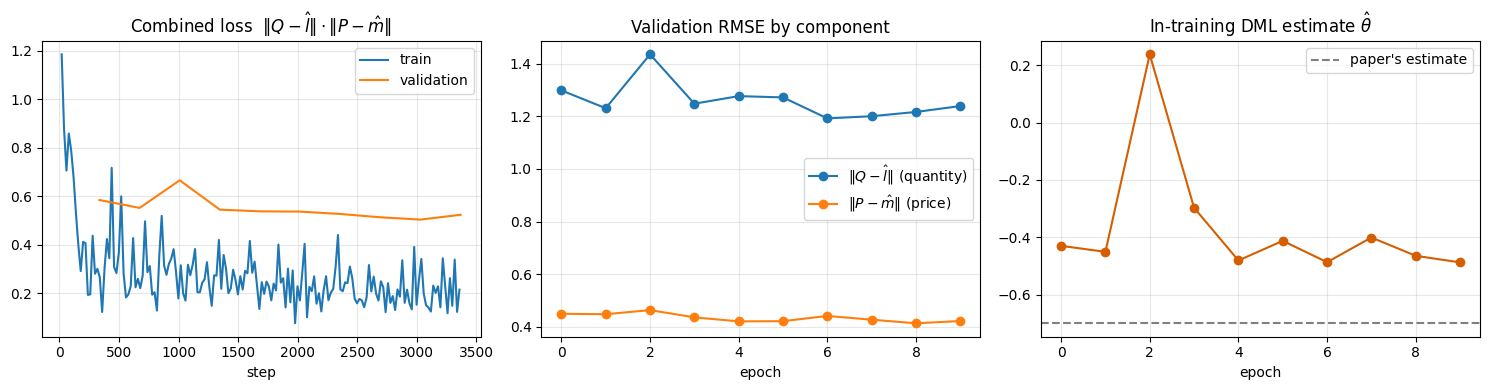

In [14]:
# one CSV per session; resumed sessions continue the step and epoch counters
logs = sorted(glob.glob(os.path.join(RUN_DIR, "logs", "version_*", "metrics.csv")))
metrics = pd.concat([pd.read_csv(p) for p in logs], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for col, lbl, ax in [("train_combined_loss", "train", axes[0]),
                     ("val_combined_loss", "validation", axes[0])]:
    if col in metrics:
        s = metrics[["step", col]].dropna()
        ax.plot(s["step"], s[col], label=lbl)
axes[0].set_title("Combined loss  $\\|Q-\\hat{l}\\|\\cdot\\|P-\\hat{m}\\|$")
axes[0].set_xlabel("step")
axes[0].legend()

for col, lbl in [("val_RMSE_ml_l_P_bb_t", "$\\|Q-\\hat{l}\\|$ (quantity)"),
                 ("val_RMSE_ml_m_P_bb_t", "$\\|P-\\hat{m}\\|$ (price)")]:
    if col in metrics:
        s = metrics[["epoch", col]].dropna()
        axes[1].plot(s["epoch"], s[col], marker="o", label=lbl)
axes[1].set_title("Validation RMSE by component")
axes[1].set_xlabel("epoch")
axes[1].legend()

if "theta_P_bb_t" in metrics:
    s = metrics[["epoch", "theta_P_bb_t"]].dropna()
    axes[2].plot(s["epoch"], s["theta_P_bb_t"], marker="o", color=palette[3])
    axes[2].axhline(-0.70, ls="--", color="gray", label="paper's estimate")
    axes[2].set_title("In-training DML estimate $\\hat{\\theta}$")
    axes[2].set_xlabel("epoch")
    axes[2].legend()

for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Extracting the embeddings

The tabular inputs change from period to period, so, as in the paper's pipeline, we compute
the embedding and the two nuisance predictions for every product-period: 21,560 rows. The
batches come from the same per-product caches as in training.

The loader walks through `df` in order (`shuffle=False`), so row $i$ of every output belongs
to row $i$ of `df`.

In [15]:
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

in_order = make_loader(np.arange(len(df)))
(pred_Q, pred_P, E), _ = lit_model.predict_numpy(trainer, in_order)
df["pred_ml_l"] = pred_Q[:, 0]
df["pred_ml_m"] = pred_P[:, 0]

assert E.shape[0] == len(df), "embedding rows are not aligned with df"
print(f"embeddings: {E.shape}   (one row per product-period, {EMB_DIM} dimensions)")

print("\nR^2 of the nuisance predictions")
for split, g in df.groupby("split"):
    print(f"  {split:10s}  Q_t: {r2_score(g['Q_t'], g['pred_ml_l']):.3f}   "
          f"P_bb_t: {r2_score(g['P_bb_t'], g['pred_ml_m']):.3f}")

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

/usr/local/lib/python3.13/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

/usr/local/lib/python3.13/dist-packages/ipywidgets/widgets/widget_output.py:112: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  self.msg_id = ip.kernel._parent_header['header']['msg_id']

/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


embeddings: (21560, 2048)   (one row per product-period, 2048 dimensions)

R^2 of the nuisance predictions
  estimation  Q_t: 0.417   P_bb_t: 0.467
  finetune    Q_t: 0.841   P_bb_t: 0.927


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Dimension Reduction

This is Algorithm 1 of the paper's Online Appendix, applied to every product-period row.

1. **Random projection.** Multiply by a Gaussian matrix to get
   $\bar{E}_i \in \mathbb{R}^{256}$. By Johnson-Lindenstrauss this approximately preserves
   pairwise distances, so it drops dimensions without distorting the geometry. Unlike a
   learned compression it needs no fitting and cannot overfit.
2. **Centre and normalise** onto the unit hypersphere:
   $$X^e_i = \frac{\bar{E}_i - \frac{1}{n}\sum_j \bar{E}_j}
                  {\|\bar{E}_i - \frac{1}{n}\sum_j \bar{E}_j\|}.$$
   Products are then compared by direction rather than magnitude.
3. **Summaries.** Five principal components
$$
X^{pc}_{i,k} = \gamma_k^\top X^e_i
$$
and five cosine similarities to the $k$-means centroids $X^{sim}_{i,k} = c_k^\top X^e_i$.

The paper works with the similarities rather than the principal components, since
closeness to the die-cast replica cluster is easier to interpret than a loading on the
second principal axis. Lab 5 uses them as the variables the elasticity depends on.

In [16]:
proj = GaussianRandomProjection(n_components=PROJECTION_DIM, random_state=SEED)
E_bar = proj.fit_transform(E)
X_e = normalize(E_bar - E_bar.mean(axis=0), axis=1)

pca = PCA(n_components=N_COMPONENTS, random_state=SEED)
X_pc = pca.fit_transform(X_e)

km = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=200).fit(X_e)
X_sim = normalize(X_e) @ normalize(km.cluster_centers_).T

emb_cols = [f"emb_{i}" for i in range(PROJECTION_DIM)]
pca_cols = [f"pca_{i}" for i in range(N_COMPONENTS)]
sim_cols = [f"similarity_cluster_{i}" for i in range(N_CLUSTERS)]

# row i belongs to df.iloc[i]
row_features = pd.concat([
    pd.DataFrame(X_e, columns=emb_cols),
    pd.DataFrame(X_pc, columns=pca_cols),
    pd.DataFrame(X_sim, columns=sim_cols),
], axis=1)

print(f"X^e: {X_e.shape}   unit norm: "
      f"{np.allclose(np.linalg.norm(X_e, axis=1), 1.0)}")
print(f"variance explained by the first {N_COMPONENTS} PCs: "
      f"{pca.explained_variance_ratio_.sum():.1%}")
print("\nrows per cluster:")
print(pd.Series(km.labels_).value_counts().sort_index().to_string())

X^e: (21560, 256)   unit norm: True
variance explained by the first 5 PCs: 37.8%

rows per cluster:
0    3518
1    5532
2    4752
3    3372
4    4386


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Checking the embeddings

Before using these vectors as controls it is worth looking at them. We run the paper's two
checks: project onto the first three principal components and colour by cluster, then read
the products closest to each centroid.

/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/local/lib/python3.13/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetim

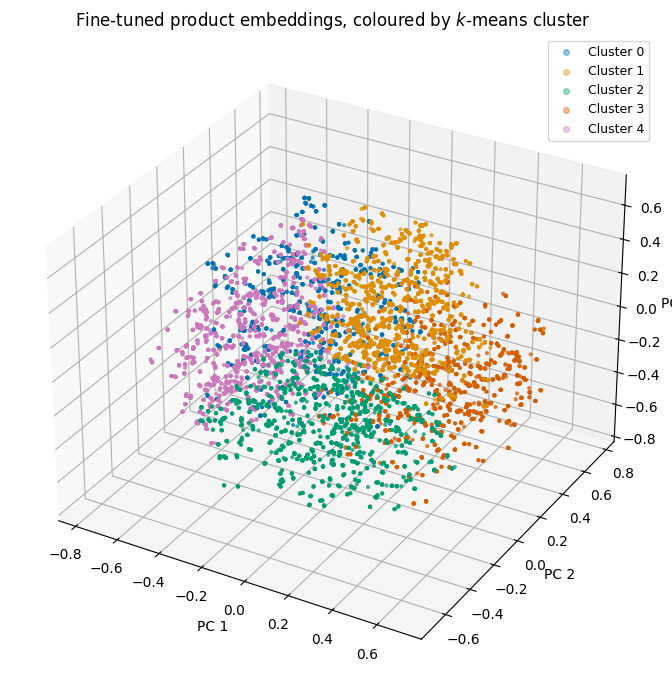

In [17]:
coords = PCA(n_components=3, random_state=SEED).fit_transform(X_e)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
for k in range(N_CLUSTERS):
    m = km.labels_ == k
    ax.scatter(coords[m, 0], coords[m, 1], coords[m, 2],
               s=4, alpha=0.4, color=palette[k], label=f"Cluster {k}")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_zlabel("PC 3")
ax.set_title("Fine-tuned product embeddings, coloured by $k$-means cluster")
ax.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.show()

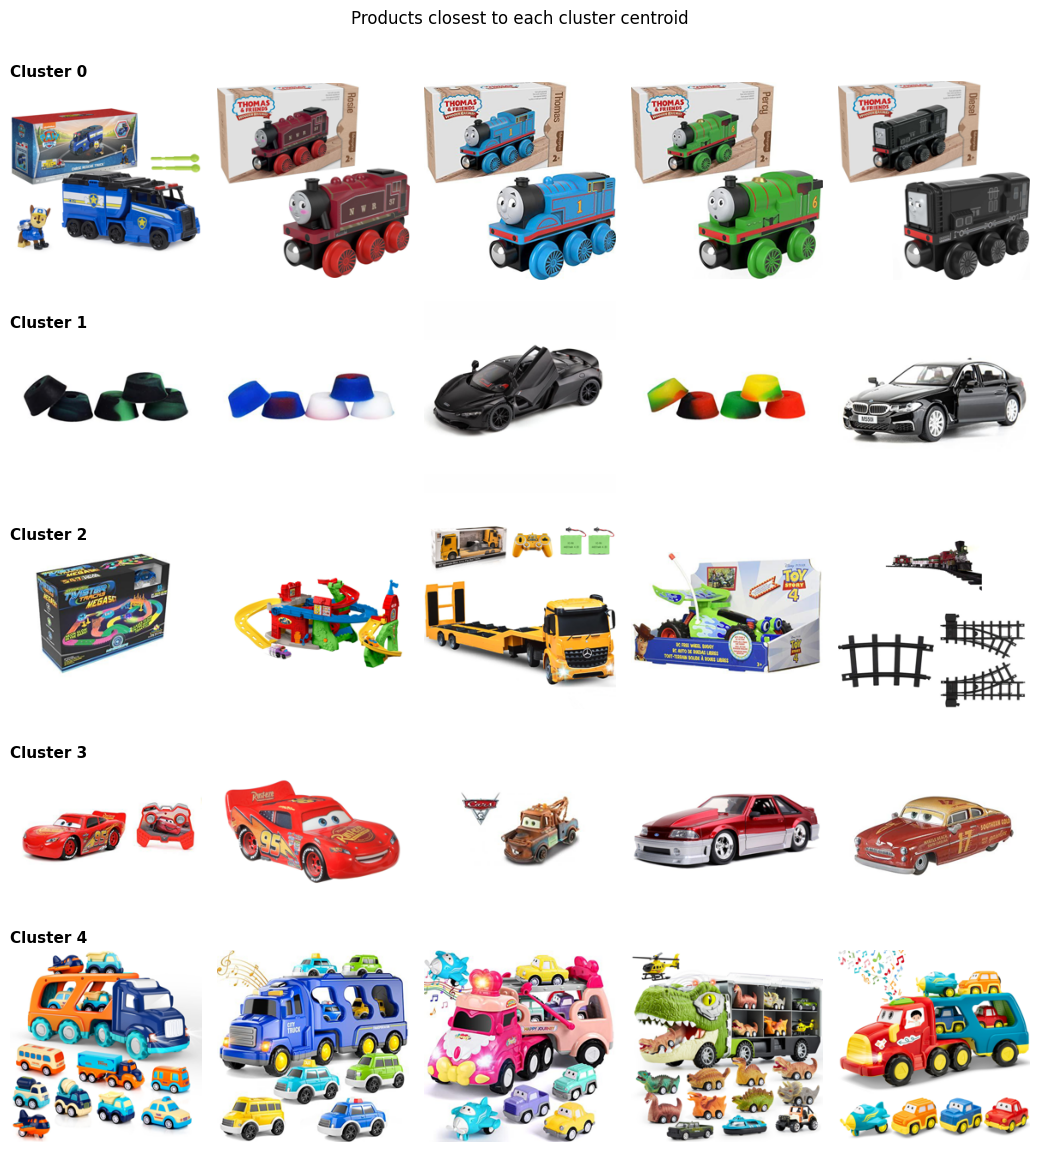


--- Cluster 0 ---
  [Trucks] Paw Patrol, Big Truck Pup’s Chase Transforming Toy Trucks with Collectible Action Figure, Kids Toys for Ages 3
  [Trains & Trams] Thomas & Friends Wooden Railway Toy Train Rosie Push-Along Wood Engine for Toddlers & Preschool Kids Ages 2+ Y
  [Train Sets] Thomas & Friends Wooden Railway Toy Train Thomas Push-Along Wood Engine for Toddlers & Preschool Kids Ages 2+ 

--- Cluster 1 ---
  [Skateboards] Teak Tuning Bubble Bushings Pro Duro Series, Black and Green Swirl - Loose (61A) - Custom Molded Fingerboard T
  [Skateboards] Teak Tuning Bubble Bushings Pro Duro Series, Red, White and Blue Swirl - Medium (71A) - Custom Molded Fingerbo
  [Cars & Race Cars] Alloy Collectible Black McLaren 720s Toy Vehicle Pull Back DieCast Car Model with Lights and Sound | Cars & Ra

--- Cluster 2 ---
  [Vehicle Playsets] Mindscope Twister Tracks Mega Set Neon Glow in The Dark Flexible Track System with 547 Pieces Over 25 Feet of 
  [Vehicle Playsets] Fisher-Price Little People

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [18]:
n_show = 5
dists = km.transform(X_e)


def closest_products(k, n):
    """Rows of the n distinct products nearest to centroid k."""
    picked, seen = [], set()
    for idx in np.argsort(dists[:, k]):
        asin = df["ASIN"].iloc[idx]
        if asin not in seen:
            seen.add(asin)
            picked.append(idx)
            if len(picked) == n:
                break
    return picked


fig, axes = plt.subplots(N_CLUSTERS, n_show, figsize=(2.1 * n_show, 2.3 * N_CLUSTERS))
for k in range(N_CLUSTERS):
    for j, idx in enumerate(closest_products(k, n_show)):
        asin = df["ASIN"].iloc[idx]
        ax = axes[k, j]
        thumb = Image.open(io.BytesIO(images[asin]))
        thumb.thumbnail((224, 224))
        ax.imshow(thumb)
        ax.axis("off")
        if j == 0:
            ax.set_title(f"Cluster {k}", loc="left", fontsize=11, weight="bold")
plt.suptitle("Products closest to each cluster centroid", y=1.005)
plt.tight_layout()
plt.show()

for k in range(N_CLUSTERS):
    print(f"\n--- Cluster {k} ---")
    for idx in closest_products(k, 3):
        row = df.iloc[idx]
        print(f"  [{row['subcat_aggregated']}] {row['text'][:110]}")

## Saving the artifact

Labs 3, 4 and 5 run in their own Colab sessions and `/content` does not survive that, so
Google Drive, mounted at the start, carries the embeddings across.

If Drive is not mounted, the notebook writes only a local copy that you can download and
upload again in the next lab.

In [19]:
TABULAR_RENAME = {
    "New Offer Count: Current": "n_offers",
    "Count of retrieved live offers: New, FBA": "n_offers_fba",
    "Count of retrieved live offers: New, FBM": "n_offers_fbm",
    "Lightning Deals: Upcoming Deal": "lightning_deal",
    "Buy Box: Is FBA": "is_fba",
}

keep = (["ASIN", "date", "period", "split", "subcat_aggregated",
         "Q_t", "P_bb_t", "Q_t-1", "P_bb_t-1", "Delta_Q_t", "Delta_P_bb_t",
         "RATING", "REVIEW_COUNT", "RATING_t-1", "REVIEW_COUNT_t-1",
         "pred_ml_l", "pred_ml_m"]
        + list(TABULAR_RENAME) + SUBCAT_COLS)

assert df.index.equals(row_features.index), "row features are not aligned with df"
artifact = pd.concat([df[keep].rename(columns=TABULAR_RENAME), row_features], axis=1)

assert artifact[emb_cols].notna().all().all(), "some rows lack an embedding"
print(f"artifact: {artifact.shape[0]:,} rows x {artifact.shape[1]:,} columns")
artifact.head(3)

artifact: 21,560 rows x 299 columns


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,ASIN,date,period,split,subcat_aggregated,Q_t,P_bb_t,Q_t-1,P_bb_t-1,Delta_Q_t,...,pca_0,pca_1,pca_2,pca_3,pca_4,similarity_cluster_0,similarity_cluster_1,similarity_cluster_2,similarity_cluster_3,similarity_cluster_4
0,1947494961,2023-01-30,0,finetune,Residual,-10.685092,3.318075,NaN,NaN,NaN,...,0.103905,-0.33096,-0.055236,-0.352174,-0.060621,-0.137945,0.087082,0.451941,-0.231857,-0.116548
1,1947494961,2023-02-27,1,finetune,Residual,-10.728496,3.435898,-10.685092,3.318075,-0.043404,...,0.103905,-0.33096,-0.055236,-0.352174,-0.060621,-0.137945,0.087082,0.451941,-0.231857,-0.116548
2,1947494961,2023-03-27,2,finetune,Residual,-11.041387,3.457206,-10.728496,3.435898,-0.312891,...,0.103905,-0.33096,-0.055236,-0.352174,-0.060621,-0.137945,0.087082,0.451941,-0.231857,-0.116548


In [20]:
ARTIFACT_NAME = "subsample_v2.parquet"
paths = [os.path.join("/content" if os.path.isdir("/content") else ".", ARTIFACT_NAME)]
if DRIVE_DIR:
    paths.insert(0, os.path.join(DRIVE_DIR, ARTIFACT_NAME))

for p in paths:
    artifact.to_parquet(p, index=False)
    print(f"wrote {p}  ({os.path.getsize(p) / 1e6:.1f} MB)")

wrote /content/drive/MyDrive/demand_labs_v2/subsample_v2.parquet  (7.8 MB)
wrote /content/subsample_v2.parquet  (7.8 MB)


In [21]:
# Optional: download the artifact to your machine instead of using Drive.
# from google.colab import files
# files.download(paths[-1])

## What we have

An embedding for every product-period, fine-tuned to predict price and quantity,
compressed to 256 dimensions and summarised by five principal components and five cluster
similarities. The network trained only on products that Labs 4 and 5 do not estimate on.
The artifact also carries the network's own nuisance predictions, `pred_ml_l` and
`pred_ml_m`.

The clusters are recognisable: die-cast replicas, large utility trucks, playsets and so
on. That says the representation is not noise, but it does not show the embeddings are
useful. For that we need to know what they predict.

* **Lab 3** measures this for $Q$, $P$, $\Delta Q$ and $\Delta P$. The gap between levels
  and changes is what the following labs turn on.
* **Lab 4** uses the embeddings as controls to estimate the average price elasticity.
* **Lab 5** uses the cluster similarities as effect modifiers, letting the elasticity vary
  across the product space.